In [ ]:
pip install pandas numpy scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

dates = pd.date_range(
    start="2026-01-01",
    periods=180,
    freq="D"
)

data = pd.DataFrame({
    "timestamp": dates
})

# Temperature data
data["temperature"] = (
    28
    + 5 * np.sin(np.arange(len(data)) / 15)
    + np.random.normal(0, 1.5, len(data))
)

# Power consumption data
data["power_kwh"] = (
    120
    + 2.5 * data["temperature"]
    + 15 * np.sin(np.arange(len(data)) / 7)
    + np.random.normal(0, 8, len(data))
)

print("Telemetry data created successfully!")
display(data.head(10))

Telemetry data created successfully!


,timestamp,temperature,power_kwh
0,2026-01-01,28.745071,196.868017
1,2026-01-02,28.125690,185.592541
2,2026-01-03,29.636226,189.751068
3,2026-01-04,31.277891,208.288086
4,2026-01-05,28.966357,198.740703
5,2026-01-06,29.284768,208.750093
6,2026-01-07,32.315911,215.915309
7,2026-01-08,31.400711,210.541212
8,2026-01-09,29.837821,201.467547
9,2026-01-10,31.637052,201.368432


In [ ]:
data["day_of_week"] = data["timestamp"].dt.dayofweek
data["day_of_month"] = data["timestamp"].dt.day
data["month"] = data["timestamp"].dt.month

# Previous power consumption
data["lag_1"] = data["power_kwh"].shift(1)
data["lag_2"] = data["power_kwh"].shift(2)
data["lag_3"] = data["power_kwh"].shift(3)

# 7-day moving average
data["rolling_7"] = data["power_kwh"].rolling(7).mean()

# Remove missing values
data = data.dropna().reset_index(drop=True)

print("Feature engineering completed!")
display(data.head())

Feature engineering completed!


,timestamp,temperature,power_kwh,day_of_week,day_of_month,month,lag_1,lag_2,lag_3,rolling_7
0,2026-01-07,32.315911,215.915309,2,7,1,208.750093,198.740703,208.288086,200.557974
1,2026-01-08,31.400711,210.541212,3,8,1,215.915309,208.750093,198.740703,202.511287
2,2026-01-09,29.837821,201.467547,4,9,1,210.541212,215.915309,208.750093,204.779145
3,2026-01-10,31.637052,201.368432,5,10,1,201.467547,210.541212,215.915309,206.438769
4,2026-01-11,30.396722,207.268233,6,11,1,201.368432,201.467547,210.541212,206.293075


In [ ]:
features = [
    "temperature",
    "day_of_week",
    "day_of_month",
    "month",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_7"
]

X = data[features]
y = data["power_kwh"]

# 80% training, 20% testing
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 139
Testing samples : 35


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
predictions = model.predict(X_test)

print("Predictions generated successfully!")

results = pd.DataFrame({
    "Date": data["timestamp"].iloc[split:].values,
    "Actual Power (kWh)": y_test.values,
    "Predicted Power (kWh)": predictions
})

display(results.head(10))

Predictions generated successfully!


,Date,Actual Power (kWh),Predicted Power (kWh)
0,2026-05-26,194.580792,198.810151
1,2026-05-27,204.422000,197.527727
2,2026-05-28,199.350435,194.998813
3,2026-05-29,202.856921,201.405903
4,2026-05-30,199.779475,203.951999
5,2026-05-31,192.041629,202.904557
6,2026-06-01,182.749851,194.271032
7,2026-06-02,184.022214,187.051961
8,2026-06-03,178.709299,190.086362
9,2026-06-04,189.443430,189.565388


In [ ]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  : {mae:.2f} kWh")
print(f"RMSE : {rmse:.2f} kWh")

MODEL PERFORMANCE
MAE  : 6.46 kWh
RMSE : 7.76 kWh


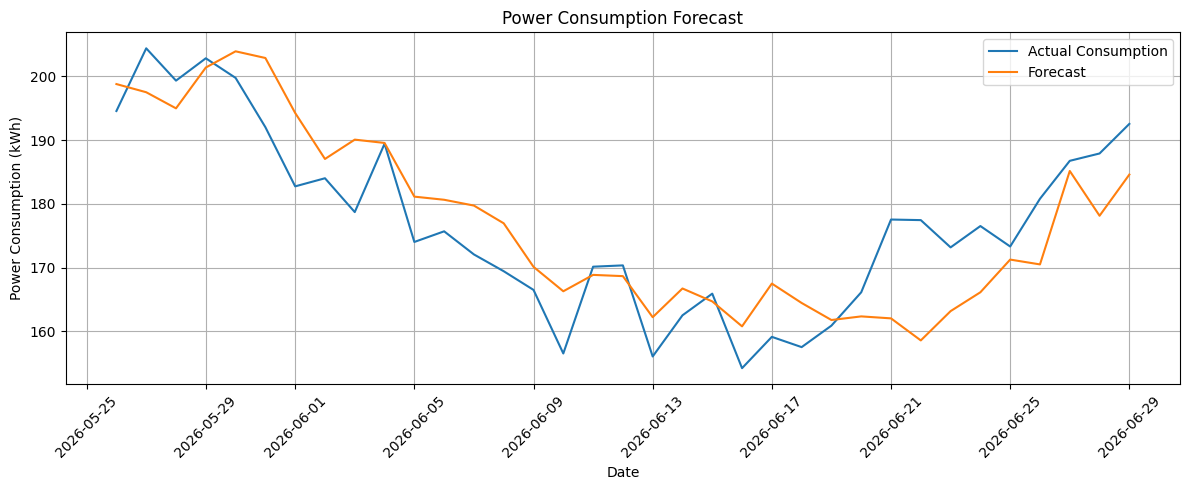

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["timestamp"].iloc[split:],
    y_test,
    label="Actual Consumption"
)

plt.plot(
    data["timestamp"].iloc[split:],
    predictions,
    label="Forecast"
)

plt.xlabel("Date")
plt.ylabel("Power Consumption (kWh)")
plt.title("Power Consumption Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def identify_intent(text):

    text = text.lower()

    if "forecast" in text or "predict" in text:
        return "POWER_FORECAST"

    elif "temperature" in text:
        return "TEMPERATURE"

    elif "alert" in text or "threshold" in text:
        return "ALERT"

    elif "power" in text or "consumption" in text:
        return "POWER_USAGE"

    else:
        return "UNKNOWN"


def extract_threshold(text):

    pattern = r"(?:above|over|exceed|greater than|threshold)\s*(\d+(?:\.\d+)?)"

    match = re.search(pattern, text.lower())

    if match:
        return float(match.group(1))

    return None

In [ ]:
last_row = data.iloc[-1]

next_day = last_row["timestamp"] + pd.Timedelta(days=1)

next_temperature = last_row["temperature"]

next_features = pd.DataFrame([{
    "temperature": next_temperature,
    "day_of_week": next_day.dayofweek,
    "day_of_month": next_day.day,
    "month": next_day.month,
    "lag_1": last_row["power_kwh"],
    "lag_2": last_row["lag_1"],
    "lag_3": last_row["lag_2"],
    "rolling_7": data["power_kwh"].tail(7).mean()
}])

forecast = model.predict(next_features)[0]

print(f"Forecast date: {next_day.date()}")
print(f"Predicted power consumption: {forecast:.2f} kWh")

Forecast date: 2026-06-30
Predicted power consumption: 185.03 kWh


In [ ]:
user_request = input(
    "Enter your telemetry request:\n> "
)

intent = identify_intent(user_request)
threshold = extract_threshold(user_request)

print("\nSTRUCTURED REQUEST")
print("=" * 40)
print("Intent:", intent)
print("Threshold:", threshold)

Enter your telemetry request:
> Show tomorrow's power forecast and alert me if it exceeds 200 kWh

STRUCTURED REQUEST
Intent: POWER_FORECAST
Threshold: None


In [ ]:
latest_power = data["power_kwh"].iloc[-1]
latest_temperature = data["temperature"].iloc[-1]

print("\nTELEMETRY RESPONSE")
print("=" * 40)

if intent == "POWER_FORECAST":

    print(
        f"Tomorrow's predicted power consumption is "
        f"{forecast:.2f} kWh."
    )

elif intent == "TEMPERATURE":

    print(
        f"Current temperature is "
        f"{latest_temperature:.2f} °C."
    )

elif intent == "POWER_USAGE":

    print(
        f"Latest power consumption is "
        f"{latest_power:.2f} kWh."
    )

elif intent == "ALERT":

    print(
        f"Forecast power consumption is "
        f"{forecast:.2f} kWh."
    )

else:

    print("Sorry, I could not understand the telemetry request.")


# Alert checking
if threshold is not None:

    print(f"\nThreshold: {threshold:.2f} kWh")

    if forecast > threshold:

        print("🚨 ALERT: Forecast exceeds the threshold!")

    else:

        print("✅ STATUS: Forecast is below the threshold.")


TELEMETRY RESPONSE
Tomorrow's predicted power consumption is 185.03 kWh.
